### Exercise 1:
Stationarity allows us to accuratrely understand how past data points are affected by distance between time rather than the time itself. 

### Exercise 1.2:

In [35]:
import statsmodels
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

(a) Generate n = 100 observations from the autoregression xt = −0.9xt−2 + wt with σw = 1,
using the method described in Example 1.8. Next, apply the moving average filter
vt = (xt + xt−1 + xt−2 + xt−3)/4 to xt, the data you generated. Now plot xt as a line and
superimpose vt as a dashed line.

<Axes: >

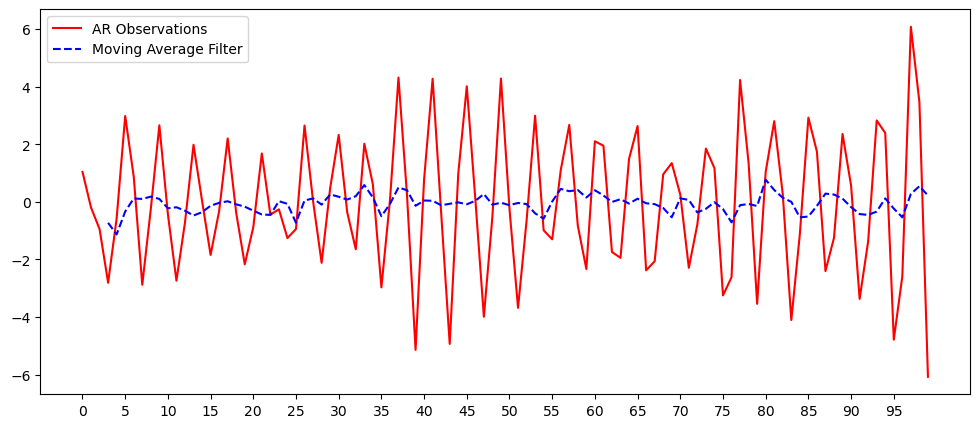

In [50]:
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.filters.filtertools import convolution_filter
ar = [1, 0, 0.9]
ma = 1
data = ArmaProcess(ar, ma).generate_sample(100)
maWeights = [0.25, 0.25, 0.25, 0.25]
vt = convolution_filter(data, maWeights, nsides =1)
tAxis = np.arange(0,100,1)
yAxis1 = data
yAxis2 = vt
plt.figure(figsize=(12,5))
plt.xticks(np.arange(0,100,5))
sns.lineplot(x=tAxis, y=data, color='red', label="AR Observations")
sns.lineplot(x=tAxis, y=vt, color='blue', label="Moving Average Filter", linestyle = "--")

(b) Repeat (a) but with xt = 2 cos(2πt/4) + wt, where wt ∼ iid N (0, 1).

<Axes: >

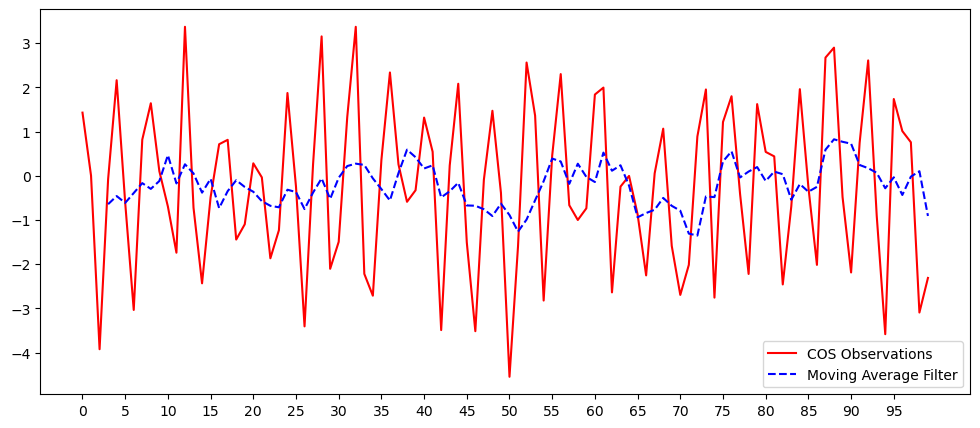

In [51]:
wt = np.random.normal(0,1,100)
xt = (2*np.cos(2*np.pi*tAxis/4)) + wt
vt = convolution_filter(xt, maWeights, nsides=1)
plt.figure(figsize=(12,5))
plt.xticks(np.arange(0,100,5))
sns.lineplot(x=tAxis, y=xt, color='red', label="COS Observations")
sns.lineplot(x=tAxis, y=vt, color='blue', label="Moving Average Filter", linestyle = "--")

(c) Repeat (a) but where xt is the log of the Johnson & Johnson data discussed in Example
1.1.

<Axes: ylabel='Value'>

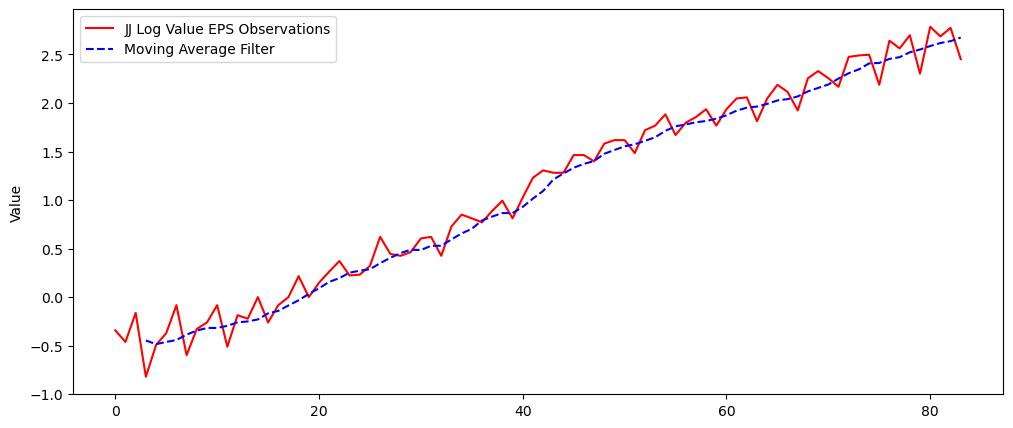

In [58]:
import astsa
df = astsa.load_jj()
logValues = np.log(df['Value'])
len(logValues)
vt = convolution_filter(logValues, maWeights, nsides=1)
tAxis = np.arange(0,84,1)
plt.figure(figsize=(12, 5))
sns.lineplot(x=tAxis, y=logValues, color='red', label="JJ Log Value EPS Observations")
sns.lineplot(x=tAxis, y=vt, color='blue', label="Moving Average Filter", linestyle = "--")